# Week 3 – Unsupervised Learning and Clustering Analysis

## YUVA Internship – Virtual Data Science with Python Trainee

This notebook performs unsupervised learning and clustering analysis on the UCI Automobile dataset. The objective is to segment automobiles into meaningful groups based on their technical and performance characteristics using the K-Means clustering algorithm.

The analysis includes data exploration, feature selection, preprocessing, feature scaling, selection of the optimal number of clusters using the Elbow Method and Silhouette Score, K-Means clustering, PCA-based visualization, cluster profiling, and interpretation of the resulting automobile segments.

## 1. Objective

The objectives of this task are:

- Apply an unsupervised learning algorithm to a public dataset.
- Segment automobiles into meaningful clusters.
- Select appropriate features for clustering.
- Standardize numerical features before applying K-Means.
- Determine a suitable number of clusters using evaluation techniques.
- Visualize the resulting clusters.
- Analyze the characteristics of each cluster.
- Discuss potential business and research implications of the clusters.

## 2. Dataset

The UCI Automobile dataset is used for this analysis. The dataset contains information about automobiles including dimensions, engine specifications, performance measures, fuel efficiency, and price.

The cleaned dataset produced during Week 1 and used for the Week 2 EDA task is used as the input for this clustering analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from IPython.display import display

sns.set_theme(style="whitegrid")

DATA_PATH = r"D:\Projects\Yuva_Intern\Task_3_Clustering\data\cleaned_automobile.csv"
OUTPUT_DIR = r"D:\Projects\Yuva_Intern\Task_3_Clustering\output"
SCREENSHOT_DIR = r"D:\Projects\Yuva_Intern\Task_3_Clustering\screenshots"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

print("Libraries imported successfully.")
print("Output and screenshot folders are ready.")

Libraries imported successfully.
Output and screenshot folders are ready.


## 3. Load the Dataset

The cleaned automobile dataset is loaded using Pandas. The dataset will be examined before selecting the variables required for clustering.

In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (205, 26)


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0


## 4. Basic Dataset Exploration

Before applying clustering, the structure, data types, missing values, and statistical properties of the dataset are examined.

In [5]:
print("Dataset Information:")
print("-" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nNumerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nStatistical Summary:")
display(df.describe().T)

Dataset Information:
--------------------------------------------------
Number of rows: 205
Number of columns: 26

Missing values:
0

Numerical columns:
['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
normalized_losses,205.0,120.600000,31.805105,65.00,101.00,115.00,137.00,256.00
wheel_base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curb_weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
engine_size,205.0,124.570732,33.974343,61.00,97.00,120.00,141.00,207.00
bore,205.0,3.329366,0.270858,2.54,3.15,3.31,3.58,3.94
stroke,205.0,3.256098,0.313634,2.07,3.11,3.29,3.41,4.17


## 5. Selecting Features for Clustering

Clustering should be based on automobile characteristics rather than the target-like variable price. Therefore, price is excluded from the clustering features.

The selected variables represent physical dimensions, engine characteristics, performance, and fuel efficiency:

- Wheel base
- Length
- Width
- Height
- Curb weight
- Engine size
- Horsepower
- City MPG
- Highway MPG

These variables provide a balanced representation of automobile characteristics.

In [6]:
clustering_features = [
    "wheel_base",
    "length",
    "width",
    "height",
    "curb_weight",
    "engine_size",
    "horsepower",
    "city_mpg",
    "highway_mpg"
]

X = df[clustering_features].copy()

print("Selected clustering features:")
for feature in clustering_features:
    print("-", feature)

print("\nClustering data shape:", X.shape)

display(X.head())

Selected clustering features:
- wheel_base
- length
- width
- height
- curb_weight
- engine_size
- horsepower
- city_mpg
- highway_mpg

Clustering data shape: (205, 9)


,wheel_base,length,width,height,curb_weight,engine_size,horsepower,city_mpg,highway_mpg
0,88.6,168.8,64.1,48.8,2548,130,111.0,21.0,27.0
1,88.6,168.8,64.1,48.8,2548,130,111.0,21.0,27.0
2,94.5,171.2,65.5,52.4,2823,152,154.0,19.0,26.0
3,99.8,176.6,66.2,54.3,2337,109,102.0,24.0,30.0
4,99.4,176.6,66.4,54.3,2824,136,115.0,18.0,22.0


## 6. Feature Distributions

The distributions of the selected clustering variables are visualized to understand their ranges and identify differences in scale before standardization.

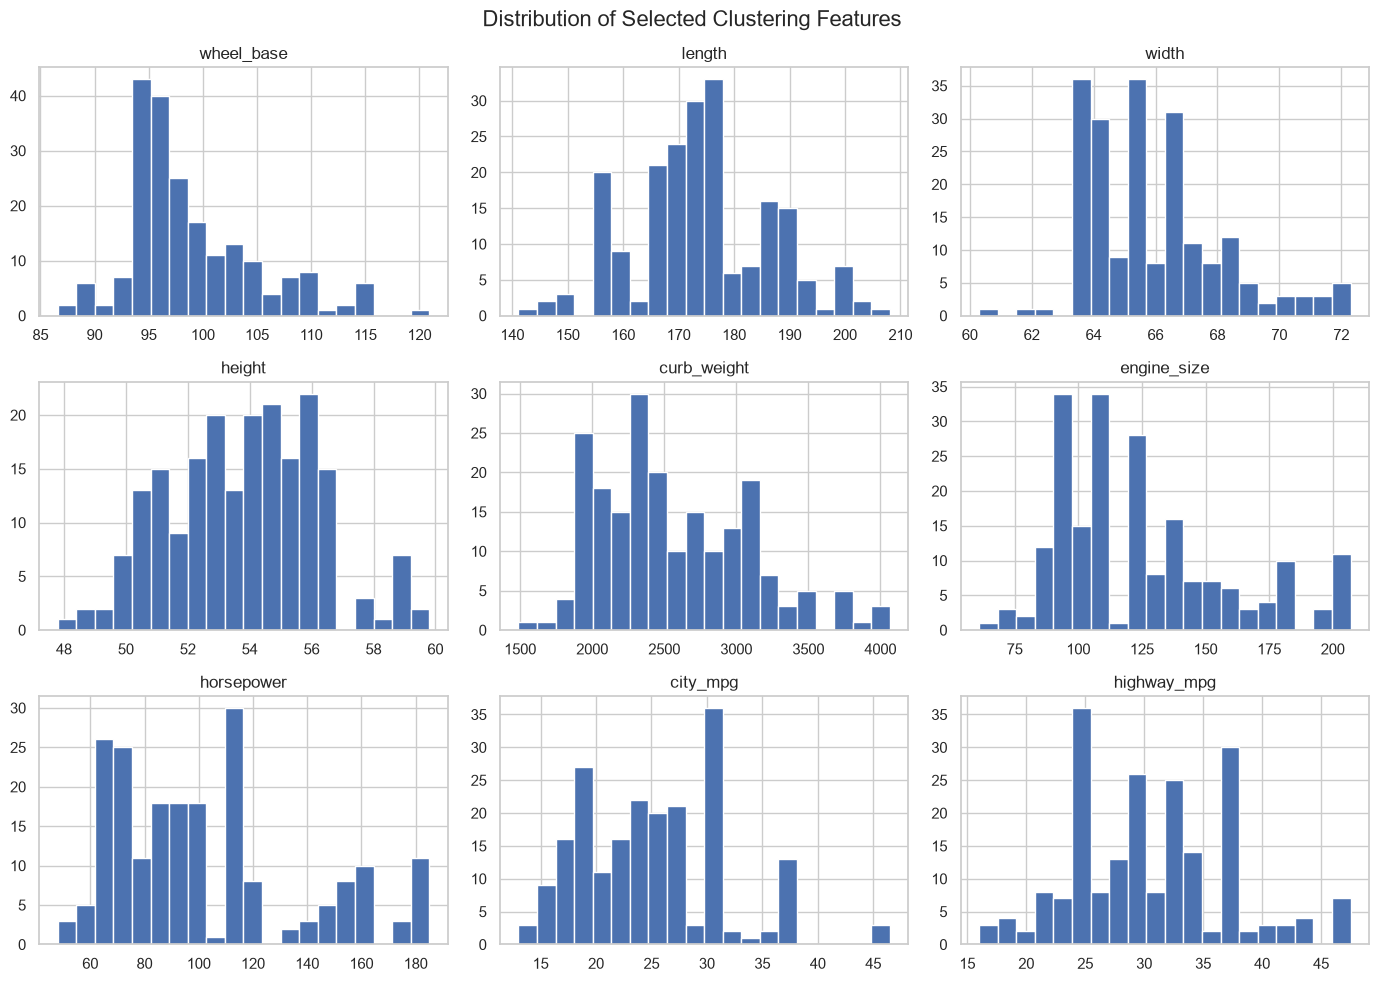

In [7]:
X.hist(figsize=(14, 10), bins=20)

plt.suptitle(
    "Distribution of Selected Clustering Features",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "03_feature_distribution.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 7. Feature Scaling

K-Means clustering uses distance calculations. Since the selected variables have different numerical ranges, StandardScaler is used to standardize the features.

After scaling, each feature has approximately zero mean and unit variance. This prevents variables with larger numerical values from dominating the clustering process.

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

print("Feature scaling completed successfully.")

display(X_scaled_df.head())

Feature scaling completed successfully.


,wheel_base,length,width,height,curb_weight,engine_size,horsepower,city_mpg,highway_mpg
0,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.160196,0.228518,-0.649321,-0.552143
1,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.160196,0.228518,-0.649321,-0.552143
2,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.809329,1.440545,-0.958163,-0.702161
3,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.459430,-0.025162,-0.186058,-0.102086
4,0.107110,0.207256,0.230001,0.235942,0.516807,0.337232,0.341265,-1.112584,-1.302237


## 8. Determining the Number of Clusters

The K-Means algorithm requires the number of clusters to be specified in advance.

To determine an appropriate value of K, two evaluation techniques are used:

1. Elbow Method – examines the reduction in within-cluster sum of squares.
2. Silhouette Score – evaluates how well each observation fits within its assigned cluster.

## 9. Elbow Method

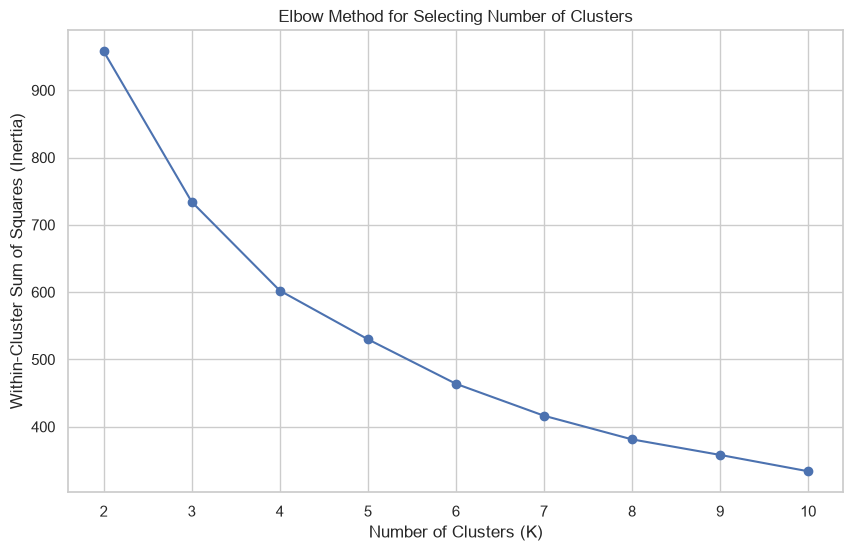

In [9]:
inertia_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "05_elbow_method.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 10. Silhouette Score Analysis

The Silhouette Score is calculated for K values from 2 to 10. A higher score indicates better separation and cohesion between clusters.

The value producing the highest silhouette score will be considered along with the Elbow Method when selecting the final number of clusters.

In [11]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_results)

best_k = int(
    silhouette_results.loc[
        silhouette_results["Silhouette Score"].idxmax(),
        "Number of Clusters"
    ]
)

best_score = silhouette_results["Silhouette Score"].max()

print("\nBest K according to Silhouette Score:", best_k)
print("Highest Silhouette Score:", round(best_score, 4))

,Number of Clusters,Silhouette Score
0,2,0.419945
1,3,0.313485
2,4,0.315148
3,5,0.311693
4,6,0.307075
5,7,0.298397
6,8,0.271007
7,9,0.281799
8,10,0.266719



Best K according to Silhouette Score: 2
Highest Silhouette Score: 0.4199


## 11. Selecting the Final Number of Clusters

The Elbow Method and Silhouette Score are considered together to select the final number of clusters.

The Silhouette Score provides a quantitative measure of cluster separation, while the Elbow Method provides a visual indication of diminishing improvement as additional clusters are introduced.

In [12]:
print("Selected number of clusters:", best_k)
print("Reason: This value provides the highest Silhouette Score among the tested K values.")

Selected number of clusters: 2
Reason: This value provides the highest Silhouette Score among the tested K values.


## 12. Applying K-Means Clustering

K-Means clustering is applied using the selected number of clusters. A fixed random state is used to make the results reproducible.

In [13]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

print("K-Means clustering completed successfully.")
print("Number of clusters:", best_k)

print("\nCluster counts:")
print(df_clustered["Cluster"].value_counts().sort_index())

K-Means clustering completed successfully.
Number of clusters: 2

Cluster counts:
Cluster
0    129
1     76
Name: count, dtype: int64


## 13. PCA-Based Cluster Visualization

The clustering process uses nine dimensions. To visualize the clusters in two dimensions, Principal Component Analysis (PCA) is used to reduce the standardized features to two principal components.

PCA is used only for visualization and does not replace the original clustering features.

Explained variance by PC1: 0.691
Explained variance by PC2: 0.172
Total explained variance: 0.863


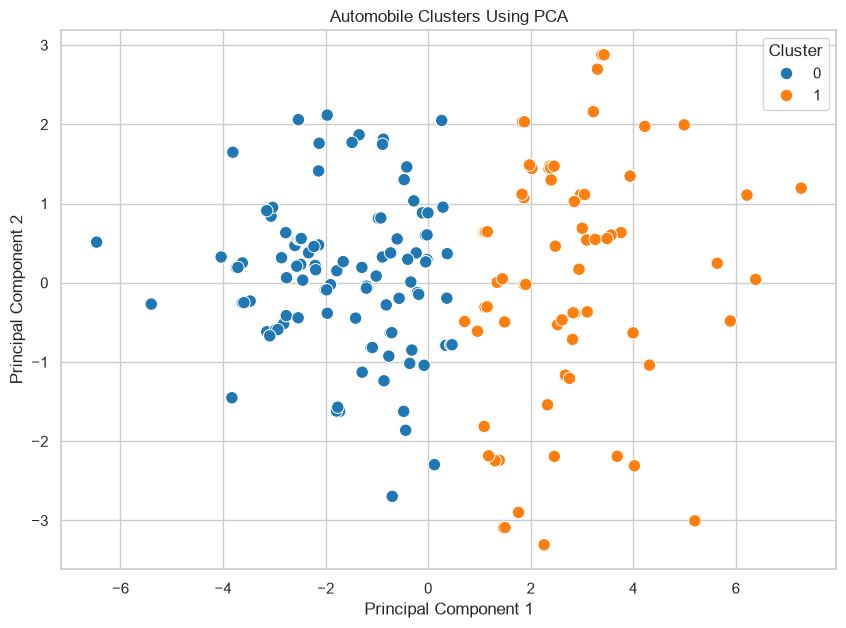

In [14]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", round(explained_variance[0], 4))
print("Explained variance by PC2:", round(explained_variance[1], 4))
print(
    "Total explained variance:",
    round(explained_variance.sum(), 4)
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("Automobile Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "08_cluster_visualization.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 14. Cluster Characteristics

To understand what makes each cluster different, the average value of each selected feature is calculated for every cluster.

This cluster profiling helps identify whether a group contains relatively larger, heavier, more powerful, or more fuel-efficient automobiles.

In [15]:
cluster_profile = df_clustered.groupby("Cluster")[clustering_features].mean()

display(cluster_profile.round(2))

,wheel_base,length,width,height,curb_weight,engine_size,horsepower,city_mpg,highway_mpg
Cluster,,,,,,,,,
0,95.91,167.32,64.70,53.25,2225.79,104.36,82.08,28.60,34.28
1,103.58,185.48,67.96,54.52,3115.32,158.88,138.22,19.45,24.57


## 15. Cluster Size Comparison

The number of automobiles in each cluster is visualized to understand the distribution of observations across the identified segments.

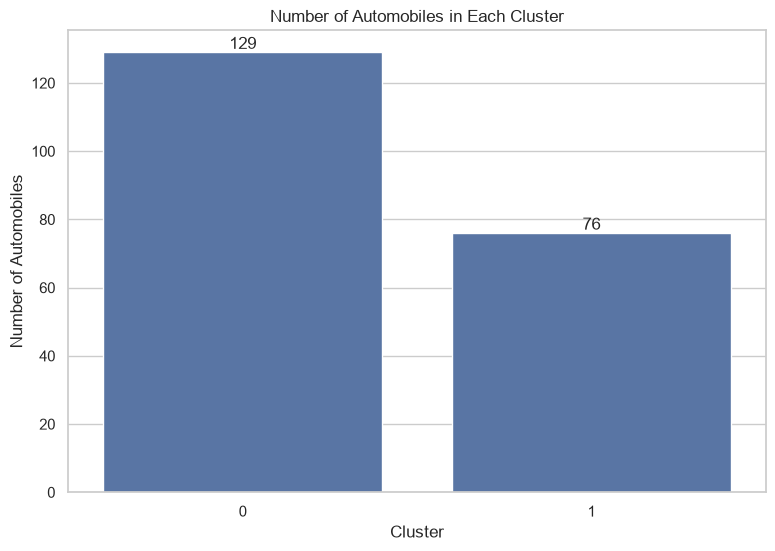

In [16]:
cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.title("Number of Automobiles in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Automobiles")

for i, value in enumerate(cluster_counts.values):
    plt.text(i, value + 1, str(value), ha="center")

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "07_cluster_sizes.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 16. Cluster Comparison

The average values of important automobile characteristics are compared across clusters. This provides a clearer understanding of how the clusters differ in terms of physical dimensions, engine characteristics, performance, and fuel efficiency.

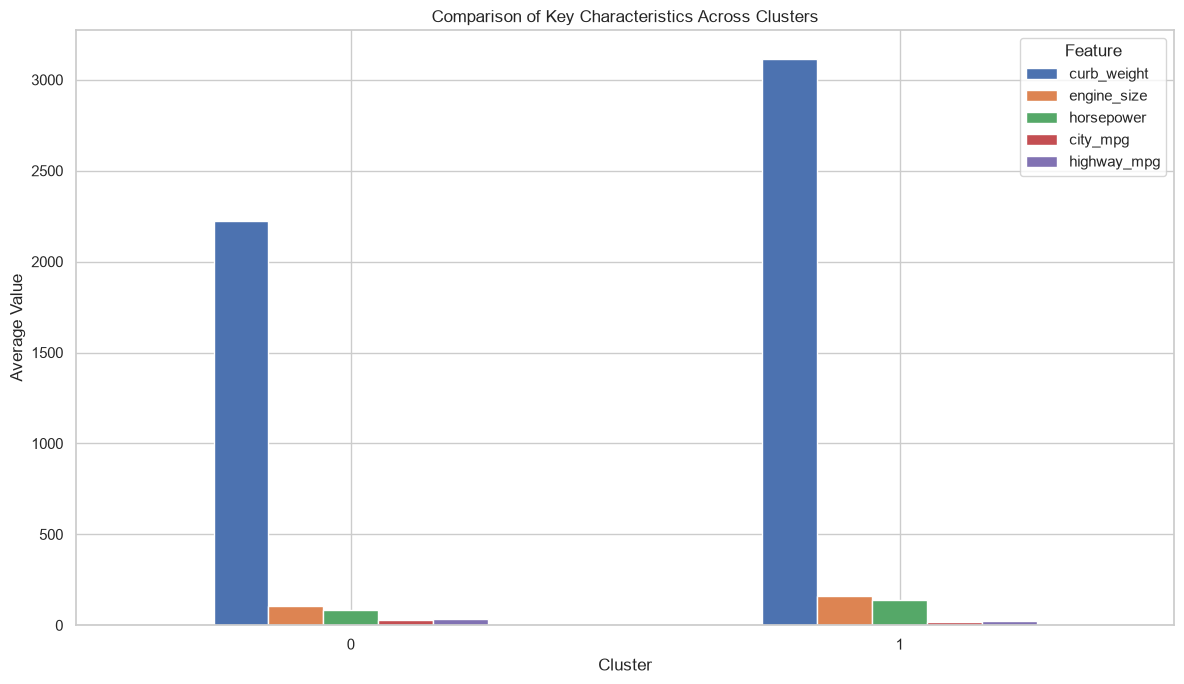

In [17]:
comparison_features = [
    "curb_weight",
    "engine_size",
    "horsepower",
    "city_mpg",
    "highway_mpg"
]

cluster_comparison = cluster_profile[comparison_features].copy()

cluster_comparison.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Key Characteristics Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(SCREENSHOT_DIR, "09_cluster_comparison.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 17. Cluster Characteristics Including Price

Price was not used as an input feature for clustering. However, it can be examined afterward to understand the economic characteristics of the resulting automobile segments.

In [18]:
price_cluster_summary = df_clustered.groupby("Cluster").agg(
    Average_Price=("price", "mean"),
    Median_Price=("price", "median"),
    Average_Horsepower=("horsepower", "mean"),
    Average_Engine_Size=("engine_size", "mean"),
    Average_Curb_Weight=("curb_weight", "mean"),
    Average_City_MPG=("city_mpg", "mean"),
    Average_Highway_MPG=("highway_mpg", "mean"),
    Number_of_Automobiles=("price", "count")
).round(2)

display(price_cluster_summary)

,Average_Price,Median_Price,Average_Horsepower,Average_Engine_Size,Average_Curb_Weight,Average_City_MPG,Average_Highway_MPG,Number_of_Automobiles
Cluster,,,,,,,,
0,8812.23,8195.0,82.08,104.36,2225.79,28.60,34.28,129
1,19334.84,17559.5,138.22,158.88,3115.32,19.45,24.57,76


## 18. Interpretation of Clusters

The clusters represent groups of automobiles with similar combinations of physical, engine, performance, and fuel-efficiency characteristics.

The cluster profiles can be interpreted by comparing their average values:

- Clusters with higher curb weight, engine size, and horsepower may represent larger or performance-oriented automobiles.
- Clusters with higher city and highway MPG may represent relatively fuel-efficient automobiles.
- Differences in average price can provide additional context about the economic positioning of each segment.

These interpretations are descriptive and are based on the characteristics observed in the dataset.

## 19. Potential Business and Research Implications

The identified automobile segments can potentially support market segmentation and exploratory research.

From a business perspective, manufacturers or marketers could use similar clustering approaches to identify groups of vehicles with comparable characteristics and understand different market segments.

For research purposes, clustering can help investigate relationships between vehicle dimensions, engine specifications, performance, fuel efficiency, and price without requiring predefined class labels.

The clusters should be interpreted as data-driven segments rather than fixed commercial categories.

## 20. Final Cluster Validation

The final dataset and clustering results are validated by checking the dataset dimensions, missing values, number of clusters, cluster counts, and silhouette score.

In [19]:
print("FINAL CLUSTERING VALIDATION")
print("=" * 50)

print("Original dataset shape:", df.shape)
print("Clustered dataset shape:", df_clustered.shape)

print("\nMissing values:", df_clustered.isnull().sum().sum())

print("Number of clusters:", df_clustered["Cluster"].nunique())

print("\nCluster counts:")
print(df_clustered["Cluster"].value_counts().sort_index())

final_silhouette = silhouette_score(
    X_scaled,
    df_clustered["Cluster"]
)

print("\nFinal Silhouette Score:", round(final_silhouette, 4))

print("\nValidation completed successfully.")

FINAL CLUSTERING VALIDATION
Original dataset shape: (205, 26)
Clustered dataset shape: (205, 27)

Missing values: 0
Number of clusters: 2

Cluster counts:
Cluster
0    129
1     76
Name: count, dtype: int64

Final Silhouette Score: 0.4199

Validation completed successfully.


## 21. Save Clustering Results

The clustered dataset, cluster profile, and clustering evaluation metrics are saved as CSV files for further analysis and documentation.

In [20]:
# Save clustered dataset
clustered_path = os.path.join(
    OUTPUT_DIR,
    "clustered_automobile.csv"
)

df_clustered.to_csv(
    clustered_path,
    index=False
)

# Save cluster profile
profile_path = os.path.join(
    OUTPUT_DIR,
    "cluster_summary.csv"
)

cluster_profile.round(2).to_csv(
    profile_path
)

# Save clustering metrics
metrics_df = pd.DataFrame({
    "Number_of_Clusters": list(k_values),
    "Silhouette_Score": silhouette_scores,
    "Inertia": inertia_values
})

metrics_path = os.path.join(
    OUTPUT_DIR,
    "clustering_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Files saved successfully:")
print("-", clustered_path)
print("-", profile_path)
print("-", metrics_path)

Files saved successfully:
- D:\Projects\Yuva_Intern\Task_3_Clustering\output\clustered_automobile.csv
- D:\Projects\Yuva_Intern\Task_3_Clustering\output\cluster_summary.csv
- D:\Projects\Yuva_Intern\Task_3_Clustering\output\clustering_metrics.csv


## 22. Conclusion

K-Means clustering was successfully applied to the UCI Automobile dataset using standardized vehicle characteristics. The number of clusters was evaluated using the Elbow Method and Silhouette Score before applying the final clustering model.

PCA was used to visualize the multidimensional clusters, while cluster profiling was performed to understand the characteristics of each automobile segment. The analysis demonstrates how unsupervised learning can identify meaningful groups in a dataset without requiring predefined labels.

The resulting clusters provide a data-driven view of automobile segments based on dimensions, engine characteristics, performance, and fuel efficiency. Examining price after clustering provides additional context for understanding the economic characteristics of each segment.

In [4]:
import pandas
import numpy
import matplotlib
import seaborn
import sklearn

print("Everything is working correctly!")

Everything is working correctly!
